# Практическая работа №5
# "Gradient Boosting"



> @Гришина Ксения, 23.Б16-мм



## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 5

> Ваша задача будет использовать различные вариации Gradient Boosting. Обязательно должен быть классический метод, далее необходимо добавить любые 2 (можно больше), которые Вас интересуют. Можно найти новые вариации из актуальных статей. Если не хочется искать, то можно рассмотреть: XGBoost, Light Gradient Boosted Machine (LightGBM), CatBoost.
> 1. Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов.
> 2. Обработать данные (взять 1 лабораторную работу).
> 3. Использовать Gradient Boosting.
> 4. Использовать вариацию 1 GB.
> 5. Использовать вариацию 2 GB.
> 6. Использовать Optuna для подбора гиперпараметров (опционально, +1 балл).
> 7. Если используете больше, чем 2 метода, можно получить дополнительные баллы.
> 8. Выберите метрики качества, на которых будете смотреть результаты обучения.
> 9. Необходимо сравнить результаты алгоритмов между собой, а также без и с использованием Optuna.
> 10. Необходимо построить графики обучения целевой функции.



> Работа должна представлять собой ноутбук в GoogleCollab или Kagle (ссылка), оставленный комментарием напротив Вашей фамилии и даты выдачи работ.

> Замечание: если будет использован GPT (как копипаст), то работа не будет засчитана. Если Вы предоставляете работу с использованием GPT - кода и это вычисляется, но это не полностью копипаст, то будет снижено 50% баллов. GPT можно использовать как источник информации, но это не должно быть скопировано и неосмысленно отправлено на проверку.

> ДД данной работы: 11.11.2025 до 23:59


## 1 Теоретическая справка

**Цель работы** -  Использовать  различные вариации Gradient Boosting.

**Задачи работы:**

- Задача регрессии на признаке `Global_Sales_log`

1. Использовать Gradient Boosting

2. Использовать CatBoost

3. Использовать LightGBM

- XGBoost.
- Использовать Optuna

**Используемые алгоритмы**:

*   Gradient Boosting (sklearn-овский)
*   1 GB (LightGBM)
*   2 GB (CatBoost)
*   3 GB (XGBoost)


> Небольшое описание алгоритмов:

**1. Gradient Boosting**

> Бустинг, использующий деревья решений в качестве базовых алгоритмов.


**2. XGBoost**

> Никто не запрещает использовать и другие алгоритмы (например, линейные модели) в качестве базовых. Эта возможность реализована в пакете XGBoost. Оптимизированная, скоростная реализация градиентного бустинга с регуляризацией и др.

**3. LightGBM**

> Разработка Microsoft. Бустинг с построением деревьев по листам (leaf-wise)

**4. CatBoost**

> Разработка Yandex. Удобен с категориальными признаками (работает “как есть”), имеет порядковую обработку категорий

Одно из основных *отличий* XGBoost, LightGBM и CatBoost — форма решающих деревьев.

- XGBoost строит деревья по принципу: «Строим дерево последовательно по уровням до достижения максимальной глубины».

- LightGBM строит деревья по принципу: «На каждом шаге делим вершину с наилучшим скором»

- CatBoost строит деревья по принципу: «Все вершины одного уровня имеют одинаковый предикат».

## 2 Обарботка данных

### Повтор практической работы №1

#### 1 Теоретическая справка

Для поиска своего набора данных воспользовалась поиском в [kaggle](https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat). Выбрала такой датасет о продажах видеоигр
(https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat)

На kaggle дали такое описание данным:



> Этот набор данных предоставляет актуальную информацию о продажах и популярности различных видеоигр по всему миру. Данные включают название, платформу, год выпуска, жанр, издателя и данные о продажах в Северной Америке, Европе, Японии и других регионах. Он также содержит оценки и рейтинги критиков и пользователей, включая средний рейтинг критиков, количество просмотренных игр, средний рейтинг пользователей, количество просмотренных игр, разработчика и рейтинг. Этот всеобъемлющий и важный набор данных предоставляет ценную информацию о мировом рынке видеоигр и является незаменимым инструментом для геймеров, профессионалов отрасли и исследователей рынка.



Записей: 16719.

**Признаки**(16 шт):
| Название колонки | Описание |
|------------------|----------|
| Name             | Название видеоигры |
| Platform         | Платформа, на которой была выпущена игра (PlayStation, Xbox, Nintendo и др.) |
| Year of Release  | Год выпуска игры |
| Genre            | Жанр видеоигры (экшен, приключения, спорт и др.) |
| Publisher        | Компания, выпустившая игру |
| NA Sales         | Продажи игры в Северной Америке (в млн USD) |
| EU Sales         | Продажи игры в Европе (в млн USD) |
| JP Sales         | Продажи игры в Японии (в млн USD) |
| Other Sales      | Продажи игры в других регионах (в млн USD) |
| Global Sales     | Общие мировые продажи игры (в млн USD) |
| Critic Score     | Средняя оценка игры от профессиональных критиков (0-100)|
| Critic Count     | Количество критиков, оценивших игру |
| User Score       | Средняя оценка игры от пользователей (0-10)|
| User Count       | Количество пользователей, оценивших игру |
| Developer        | Компания, разработавшая игру |
| Rating           | Возрастной рейтинг игры (ESRB, PEGI и др.) |


На этих данных можно выполнять **задачи**:
- первичный анализ данных (есть пропуски и некорректные типы данных)
- регрессии (наиболее естественная, предсказать Global_Sales)
- классификации (например, по рейтингу или платформе)
- кластеризации (группировать схожие игры)

**Задача на эту работу** - первичный анализ данных.
по содержанию ноутбука будет видно, какие шаги для этого потребовалось выполнить.

#### 2 Датасет

- Датасет индивидуален, был привязан ко мне комментарием в табличке курса

Есть несколько способов подгрузить данные в colab - через `mount` и директорию в google Drive чтобы он подгружался при каждой сессии, через kagglehub и т.д. Я воспользуюсь наиболее простым вариантом - загружу скачанный `csv`-файл в Файлы collab'а, но надо держать в уме что при следующих сессиях использования ноутбука есть шанс его "исчезновения" и надо будет вновь его туда добавить.

##### ∀ Импорты

In [1]:
!pip install optuna
!pip install catboost

In [2]:
import os
from google.colab import drive
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

import optuna

Считаем скачанный датасет

In [3]:
# 1. Добавлять напрямую, так делала в работе №1
# data = pd.read_csv('Video_Games.csv')

# 2. через mount. Это удобнее, так делаю в работе №2 и далее
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/Video_Games.csv')

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [4]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Все успешно подгрузилось.
- Заметим, что в данных **есть пропуски, как количественые, так и категориальные признаки**

Также, сразу узнаем основную информацию о датафрейме "по факту"

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `'Year_of_Release'` типа `float`)

**Вывод**: датасет согласуется с требованиями (не самый чистый).

#### 3 Обработка пропусков

из инфо выше видно, что у двух записей не хватает названия игры. можно предположить, что данные там некорректно собирались, и по логике их можно удалить.

In [6]:
# Удаляем строки, где Name пустое
data = data.dropna(subset=['Name'])

Заполним медианой год выпуска

In [7]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())

Заполним модой издателя

In [8]:
# Категориальные признаки заполним модой
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


для признаков, связанных с оценками очень много пропусков (~8к). удалив их мы потеряем половину датасета, а заполнив медианой придется учитывать, что мы могли исказить исходное распределение.



In [10]:
data['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [11]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


In [13]:
# при попытке заполнить пропуски вышла ошибка, посмотрим какие значения принимает этот признак
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [14]:
tbd_count = (data['User_Score'] == 'tbd').sum()
print(f"Количество 'tbd': {tbd_count}")

Количество 'tbd': 2425


In [15]:
# Преобразуем в числа, нечисловые значения станут NaN
data['User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')
# Заполним их медианой
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Проверка
data['User_Score'].unique()

array([8. , 7.5, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 2.6, 7.2, 9.2,
       7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8, 6.1,
       6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8, 5.6,
       5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5, 2.5,
       1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. , 1.6,
       9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2, 0.6,
       1.4, 0.9, 1. , 9.7])

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


In [17]:
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

Так как пропуски в этих признаках есть в почти половине записей, заполнять стат методами мы можем изменить распределение. Создадим новую категорию, чтобы не искажать исходные данные.

In [18]:
# заполняем пропуски в рейтинге значением "неизвестно"
data["Rating"] = data["Rating"].fillna("Unknown")
data["Developer"] = data["Developer"].fillna("Unknown")

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       16717 non-null  float64
 14  Developer        16717 non-null  object 
 15  Rating           16717 non-null  object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


**Вывод**: заполнили пропуски, стараясь сохранить реальность данных и применимость к основным задачам датасета

#### 4 Обработка выбросов

Для начала, было бы неплохо узнать, есть ли они вообще. Для этого посмотрим на Q3 и max в инфо или на боксплотах.

In [20]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.00000,16717.000000
mean,2006.497218,0.263255,0.145010,0.077610,0.047333,0.533462,70.010767,23.609380,7.32976,86.760364
std,5.830342,0.813475,0.503303,0.308836,0.186721,1.547956,9.776915,13.510184,1.02779,384.399216
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


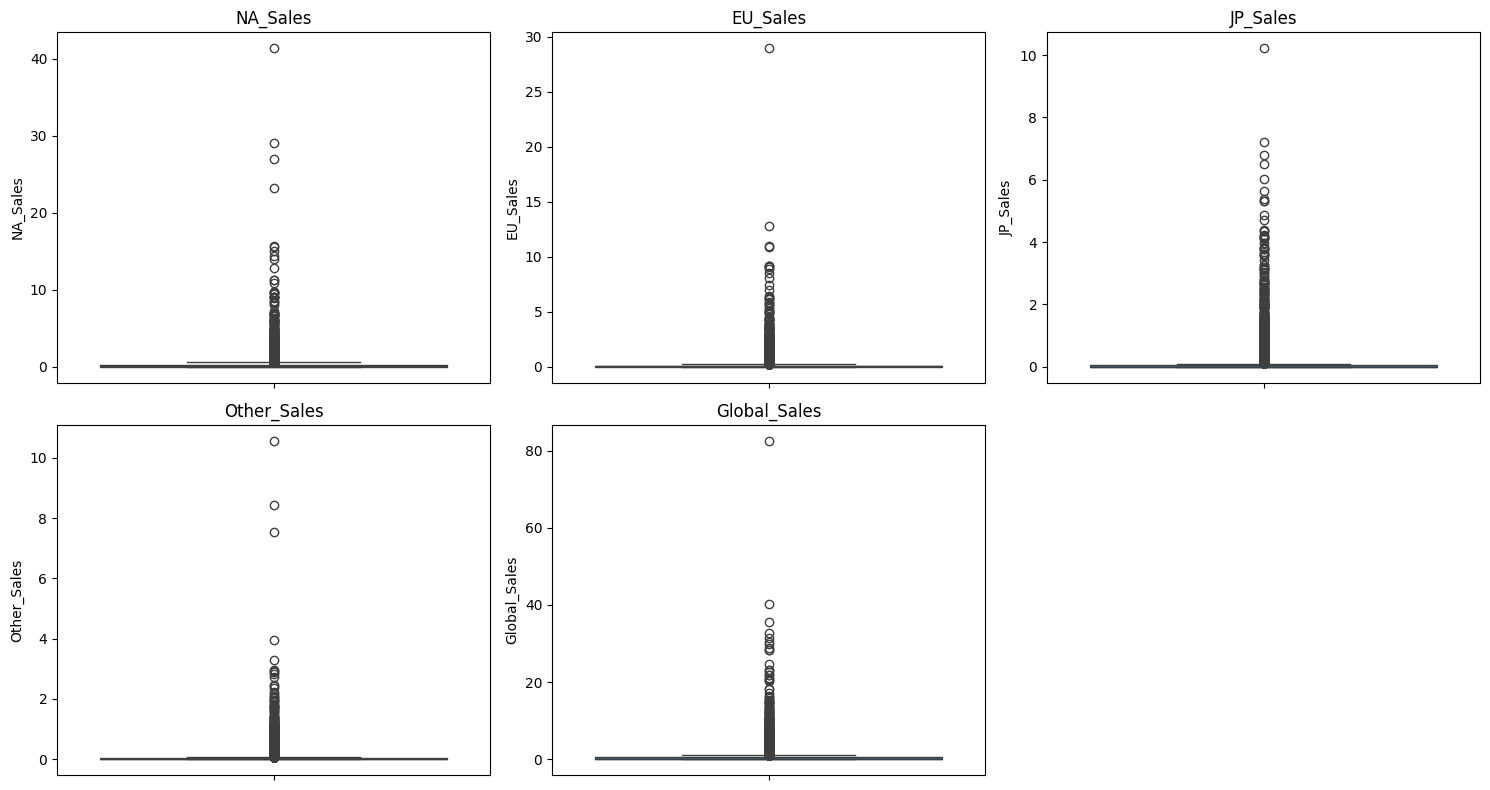

In [21]:
# Список столбцов продаж
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(15, 8))

# Проходим по каждому столбцу и строим боксплот
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)  # создаём сетку 2x3
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Выяснили, что наши данные очень асимметричны, т е что есть и очень успешные игры, с продажами сильно выше среднего, и провальные проекты. Но в основном у нас не совсем так, поэтому на них можно смотреть как на выбросы. (Зависит от задачи.)

Прологарифмировав данные мы можем избавиться от тяжелых хвостов и сделать их более симметричными.

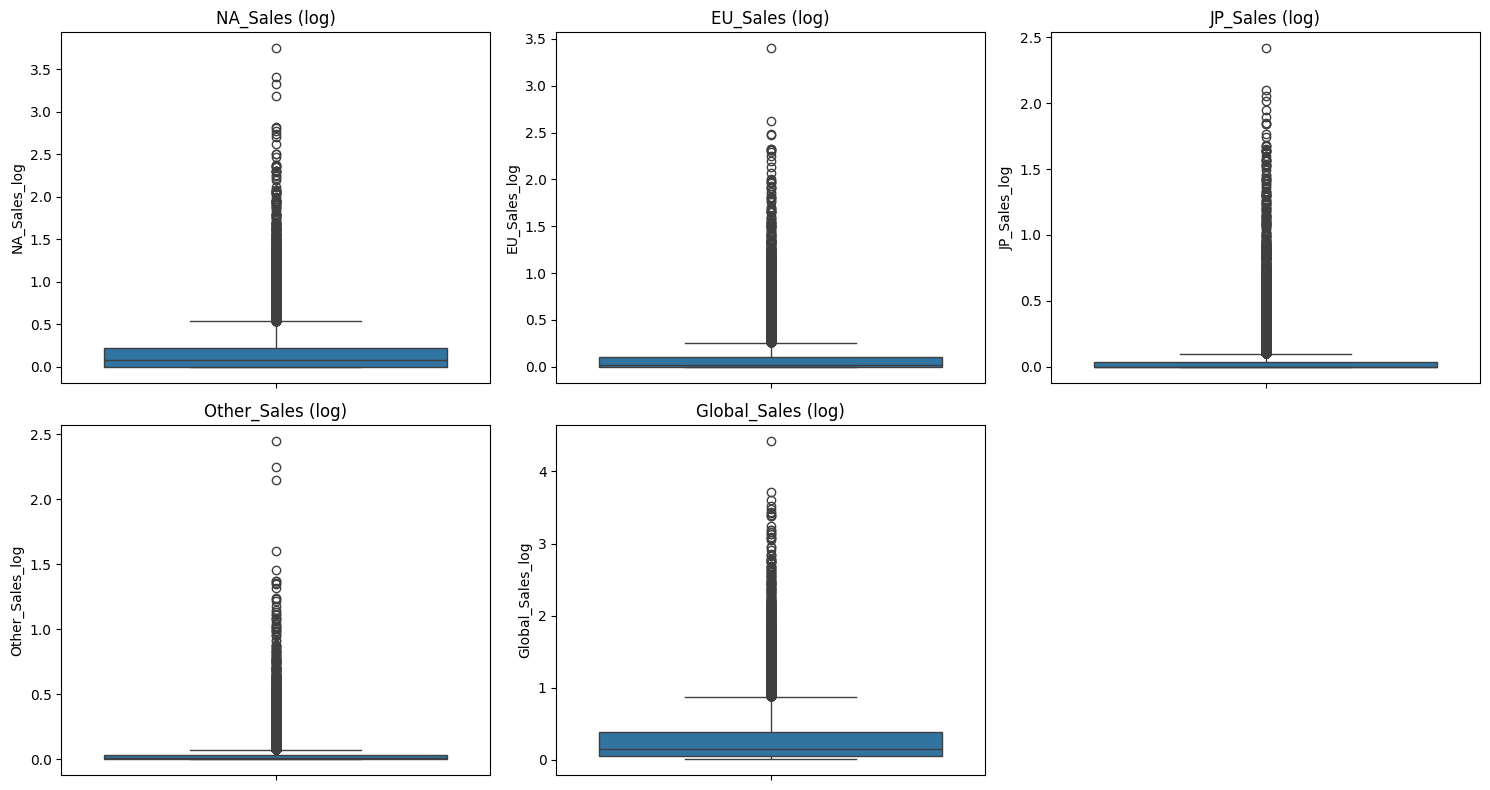

In [22]:
# создаём логарифмированные столбцы
for col in sales_cols:
    data[col + '_log'] = np.log1p(data[col])

# визуализация
plt.figure(figsize=(15, 8))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col + '_log'])
    plt.title(col + ' (log)')

plt.tight_layout()
plt.show()

При использовании межквартильного размаха для удаления выбросов мы потреяем большую часть данных(~6k).

In [23]:
sales_log_cols = ['NA_Sales_log', 'EU_Sales_log', 'JP_Sales_log', 'Other_Sales_log', 'Global_Sales_log']

for col in sales_log_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # оставляем только строки без выбросов
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [25]:
# Был другой вариант: Чтобы не удалять столько записей,
# и терять хитов индустрии, можно было их обработать - подрезать
# экстремальные значения сверху и снизу на до границ IQR. Так хиты останутся,
# но их значения будут не так разбросаны. Боксплоты будут вообще без выбросов.

# я решила так не делать, так как на мой взгляд это сильно искажает
# реальную картину, но может это не так.


# # sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# for col in sales_cols:
#     lower = data[col].quantile(0.25)
#     upper = data[col].quantile(0.75)
#     data[col] = data[col].clip(lower, upper)

# print(data[sales_cols].describe())

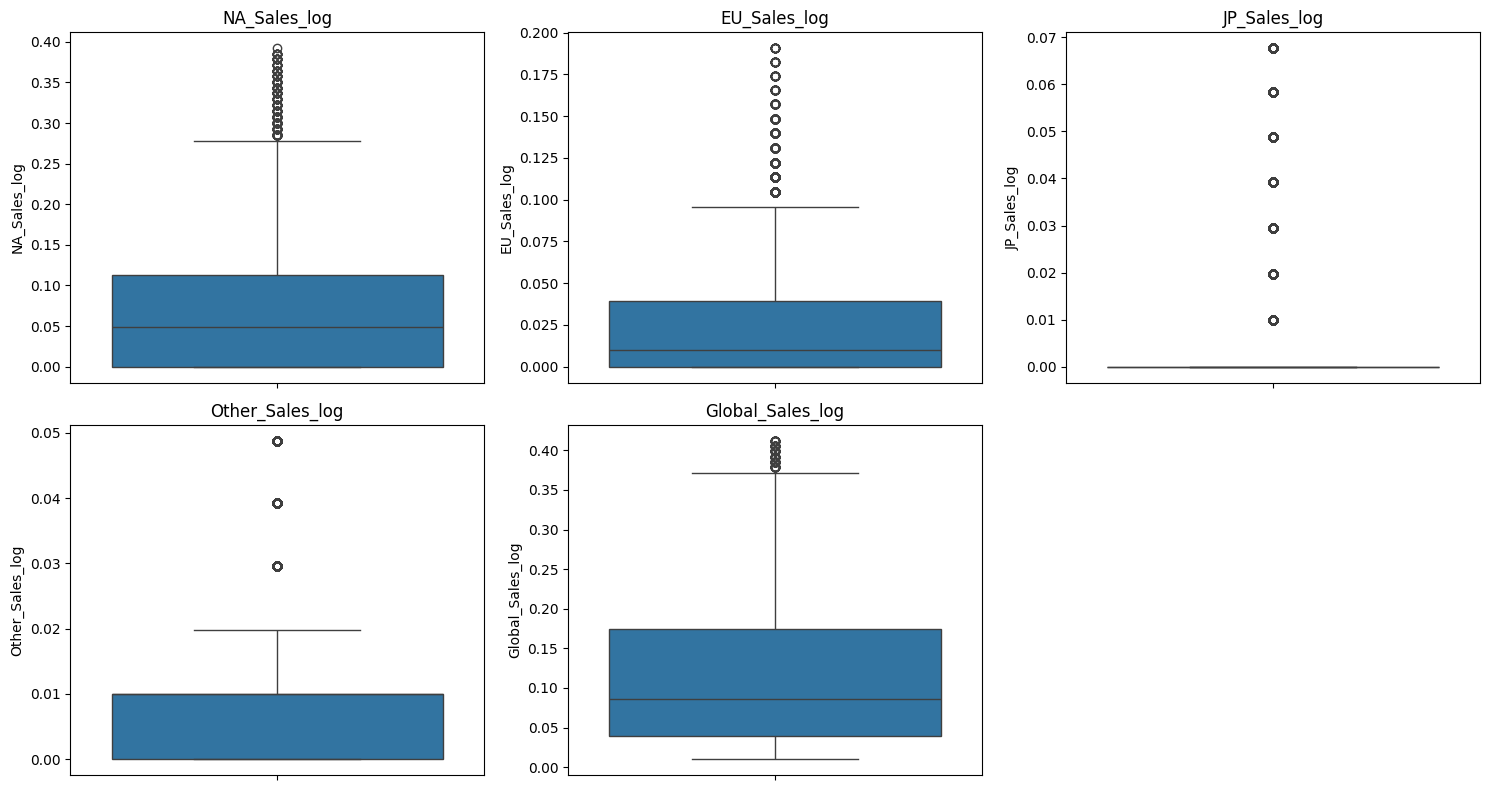

In [26]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(sales_log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Ситуация с выбросами стала лучше.
Хотя точки выше новых "усов" все еще есть, их гораздо меньше чем было изначально.

**Вывод:** с помощью ящика с усами обнаружили выбросы в продажах, удалили их с помощью межквартильного размаха.

#### 5 Обработка неправильных типов данных

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [28]:
# object -> int (можно в datetime)
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

In [29]:
# float -> int (там только целые значения)
int_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']

for col in int_cols:
    data[col] = data[col].astype(int)

In [30]:
# object -> категориальные
cat_cols = [ 'Platform', 'Genre', 'Rating',  'Name', 'Publisher', 'Developer']

for col in cat_cols:
    data[col] = data[col].astype('category')

In [31]:
print(data.info())

data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Name              10671 non-null  category
 1   Platform          10671 non-null  category
 2   Year_of_Release   10671 non-null  int64   
 3   Genre             10671 non-null  category
 4   Publisher         10671 non-null  category
 5   NA_Sales          10671 non-null  float64 
 6   EU_Sales          10671 non-null  float64 
 7   JP_Sales          10671 non-null  float64 
 8   Other_Sales       10671 non-null  float64 
 9   Global_Sales      10671 non-null  float64 
 10  Critic_Score      10671 non-null  int64   
 11  Critic_Count      10671 non-null  int64   
 12  User_Score        10671 non-null  int64   
 13  User_Count        10671 non-null  int64   
 14  Developer         10671 non-null  category
 15  Rating            10671 non-null  category
 16  NA_Sales_log      10671 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,35,5,22,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211


**Вывод**: привели все признаки к корректным типам:

- Числовые признаки (`Year_of_Release`, `User_Score`, `Critic_Score`, `Critic_Count`, `User_Count`, `Sales`'ы) были приведены к `float` или `int`.

- Качественные признаки (`Platform`, `Genre`, `Publisher`, `Developer`, `Rating`, `Name`) были приведены к типу `category`.

После этой обработки все данные стали однородными, нет типа `object`.

#### 6 Преобразование качественных признаков

Этих категорий, которые представлены ниже, не так много, как в остальных качественнных признаках


In [32]:
print(data.Platform.unique())
print(data.Genre.unique())
print(data.Rating.unique())

['X360', '2600', 'DS', 'GC', 'PS', ..., '3DO', 'GG', 'WS', 'PCFX', 'TG16']
Length: 31
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']
['Action', 'Sports', 'Role-Playing', 'Puzzle', 'Adventure', ..., 'Fighting', 'Shooter', 'Racing', 'Simulation', 'Strategy']
Length: 12
Categories (12, object): ['Action', 'Adventure', 'Fighting', 'Misc', ..., 'Shooter', 'Simulation',
                          'Sports', 'Strategy']
['E', 'Unknown', 'E10+', 'T', 'M', 'EC', 'RP', 'K-A']
Categories (8, object): ['E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', 'Unknown']


их можно закодировать.


Если спользовать `One Hot Encoding`, то это приведет к раздуванию датасета.

Используем `LabelEncoder`, в нем каждой категории присваивается число (напр `PS3 - 1, Wii - 2, PC - …`)

In [33]:
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Rating']:
    data[col + '_code'] = le.fit_transform(data[col])
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,Unknown,Unknown,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7


Однако качественные признаки `'Name'`, `'Publisher'`, `'Developer'` остались незакодированными.

(`Name` можно было бы и удалить вовсе, так как в моделях вероятнее всего этот признак не будем использовать, но пока пусть остается.)

Так как их уникальных значений очень много, можно закодировать их через `frequency encoder` (не значениями `0,...,k` а их частотой появления в дф, это дает меньше аффекта для линейных моделей, которые могуть считать новые признаки упорядоченными)



In [34]:
for col in ['Publisher', 'Developer', 'Name']:
    freq = data[col].value_counts() / len(data)
    data[col + '_freq_code'] = data[col].map(freq)
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094


**Вывод**: закодировали качественные признаки методами `Label&Frequency Encoder`

#### ❓Удалим старые признаки


Так как мы преобразовали исходные признаки (логарифмировали, закодировали категориальные), первоначальные признаки можно убрать из датасета, ибо они по сути дублируют информацию и все равно будут сильно коррелировать с новыми признаками. Однако потом их нельзя будет использовать для визуализации.

In [35]:
data.drop(columns=['Name', 'Platform', 'Genre', 'Publisher','NA_Sales',
                   'EU_Sales','JP_Sales','Other_Sales','Global_Sales','Developer',
                   'Rating'], inplace=True)

#### 7 Разделение выборки (на тренировочную, тестовую, валидационную)

Разделим выборку в соотношении `60/20/20`




In [36]:
# X — все признаки,
# y — целевая переменная (например, Global_Sales_log)
# При интерпертации результатов надо будет вернуться (y_pred_real = np.expm1(y_pred_log))
X = data.drop(columns=['Global_Sales_log'])
y = data['Global_Sales_log']

# сначала выделяем тренировочную 60% и временную 40% (для валидации и теста)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# затем делим оставшиеся 40% пополам: 20% валидация, 20% тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# проверим размеры выборок
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (6402, 15) Validation: (2134, 15) Test: (2135, 15)


или в процентах:

In [37]:
n_total = len(data)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/n_total*100:.1f}%)")

Train: 6402 (60.0%)
Validation: 2134 (20.0%)
Test: 2135 (20.0%)


как и ожидалось.

**Вывод**: При `random_state=42` разделили выборку на три части:

- Тренировочная выборка (`X_train, y_train`) — 60% данных (используется для обучения моделей)

- Валидационная выборка (`X_val, y_val`)— 20% данных (используется для подбора гиперпараметров и контроля переобучения)

- Тестовая выборка (`X_test, y_test`)— 20% данных (используется для финальной оценки качества модели)

#### 8 Стандартизация данных

Цель — преобразовать исходный набор в новый со средним значением равным 0 и стандартным отклонением равным 1.

Стандартизация нужна, чтобы все числовые признаки имели одинаковый масштаб. Это важно для некоторых чувствительных к нему моделей.

У нас, например, оценки критиков(0-100) и игроков(0-10) меняются в разных масштабах.

Стандартизуем числовые признаки.

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 non-null  float64
 15  Name_freq_code       10671 non-null  f

In [39]:
scaler = StandardScaler()

# выбираем признаки для стандартизации
num_features = [
    'Year_of_Release',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'NA_Sales_log',
    'EU_Sales_log',
    'Other_Sales_log'
]

# fit на train
scaler.fit(X_train[num_features])

# трансформируем train, test, val
X_train[num_features] = scaler.transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])

**Вывод**: стандартизировали числовые признаки (`'Year_of_Release','Critic_Score','Critic_Count',
'User_Score',
'User_Count',
'NA_Sales_log',
'EU_Sales_log',
'Other_Sales_log'`) с помощью `StandardScaler`

#### 9 Визуализация

Построим различные графики для визуализации наших данных.

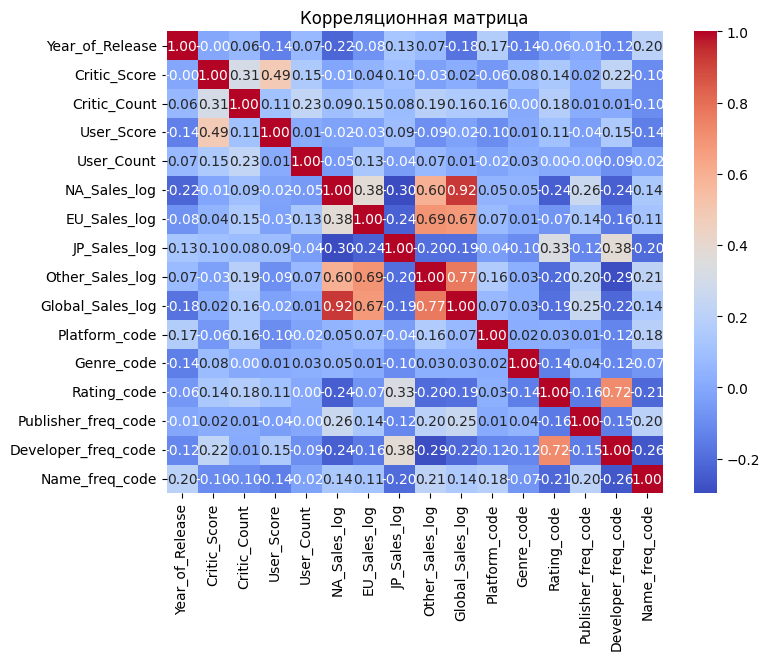

In [40]:
# 1.Корреляционная матрица
external_corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(external_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

In [41]:
# 2.Диаграмма рассеяния
# sns.pairplot(data=data)

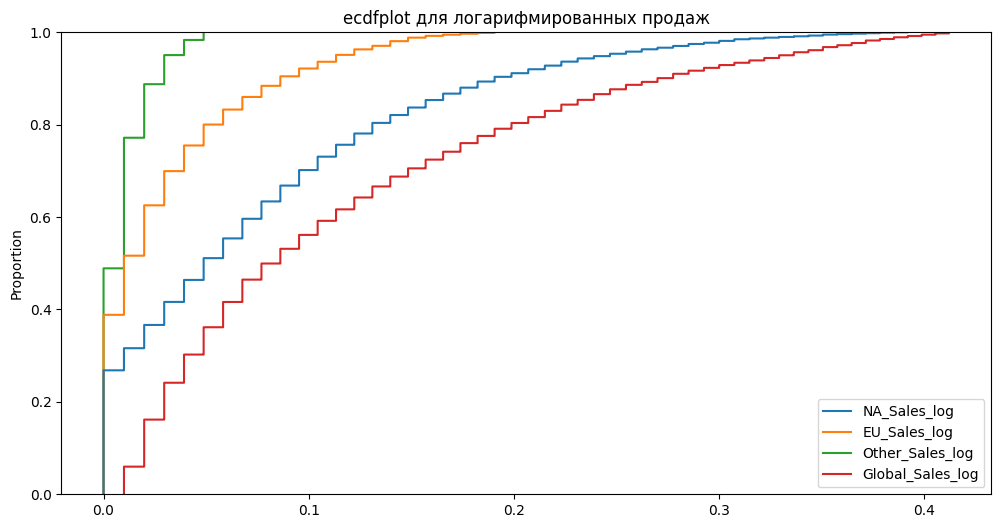

In [42]:
# 3. ecdfplot по регионам продаж
plt.figure(figsize=(12, 6))
sns.ecdfplot(data=data[['NA_Sales_log', 'EU_Sales_log', 'Other_Sales_log', 'Global_Sales_log']])
plt.title("ecdfplot для логарифмированных продаж")
plt.show()

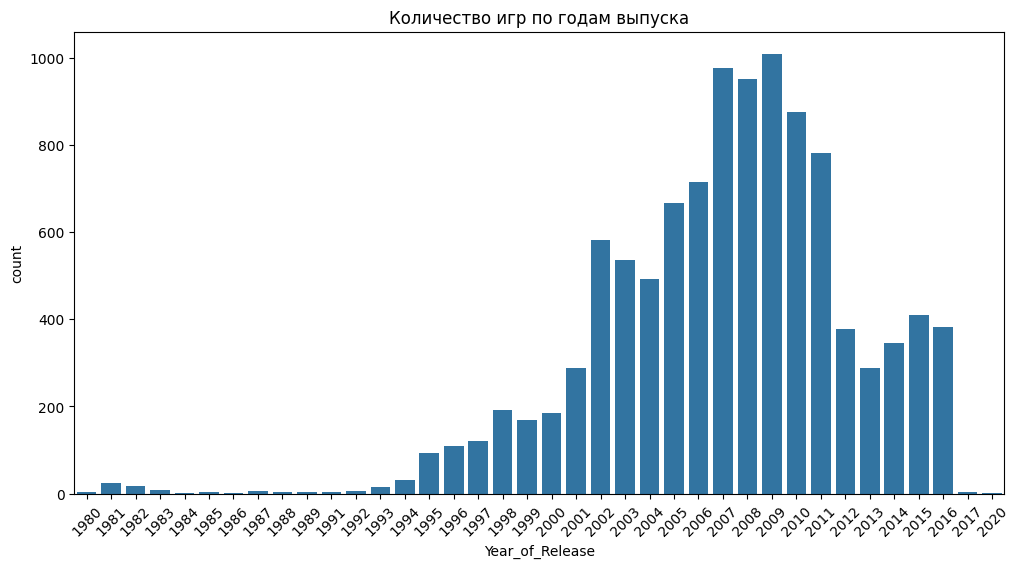

In [43]:
# 4. Тренд по годам
plt.figure(figsize=(12, 6))
sns.countplot(x="Year_of_Release", data=data)
plt.xticks(rotation=45)
plt.title("Количество игр по годам выпуска")
plt.show()

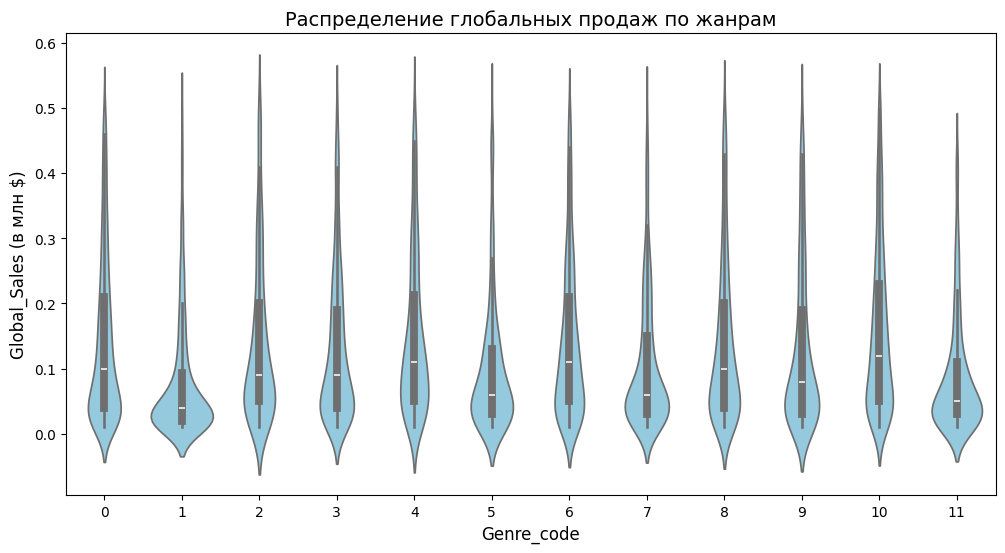

In [44]:
# 5. Скрипичная диаграмма
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Genre_code",
    y=np.expm1(data["Global_Sales_log"]),
    data=data,
    inner="box",
    color="skyblue"
)

plt.title("Распределение глобальных продаж по жанрам", fontsize=14)
plt.xlabel("Genre_code", fontsize=12)
plt.ylabel("Global_Sales (в млн $)", fontsize=12)
plt.show()

**Вывод**: визуализация позволяет наглядно увидеть распределение признаков, выявить выбросы, зависимости

#### 10 Методы описания данных

Используем ≥ 8 разных методов описания данных

In [45]:
print("1. Размерность датасета:", data.shape)

print("\n2.Информация о данных:")
display(data.info())

print("\n3.Первые 5 строк:")
display(data.head())

print("\n4.Последние 5 строк:")
display(data.tail())

print("\n5.Основная статистика (числовые признаки):")
display(data.describe())

print("\n6.Количество пропусков:")
display(data.isnull().sum())

print("\n7.Количество уникальных значений:")
display(data.nunique())

print("\n8.Корреляция:")
display(data.corr())

print("\n9.оценка использования памяти:")
display(data.memory_usage(deep=True))

1. Размерность датасета: (10671, 16)

2.Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 

None


3.Первые 5 строк:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,2012,59,35,5,22,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,2007,71,21,7,24,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094
3885,2008,70,26,7,14,0.307485,0.104360,0.0,0.039221,0.41211,4,7,1,0.011714,0.000094,0.000094
3889,2003,94,19,7,17,0.336472,0.095310,0.0,0.009950,0.41211,7,10,0,0.062974,0.003655,0.000187
3893,1997,71,21,7,24,0.246860,0.173953,0.0,0.029559,0.41211,15,10,7,0.002437,0.375129,0.000094



4.Последние 5 строк:


...

,0
Year_of_Release,38
Critic_Score,79
Critic_Count,83
User_Score,10
User_Count,444
NA_Sales_log,49
EU_Sales_log,22
JP_Sales_log,8
Other_Sales_log,6
Global_Sales_log,51



8.Корреляция:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
Year_of_Release,1.000000,-0.004974,0.063585,-0.135394,0.072110,-0.221161,-0.082508,0.126732,0.074327,-0.175783,0.172315,-0.140934,-0.061649,-0.005263,-0.115052,0.199811
Critic_Score,-0.004974,1.000000,0.306266,0.486239,0.149531,-0.012382,0.042722,0.101755,-0.031612,0.017338,-0.062463,0.078423,0.141035,0.018273,0.221947,-0.100208
Critic_Count,0.063585,0.306266,1.000000,0.105460,0.230355,0.093304,0.154477,0.081121,0.186785,0.155537,0.158673,0.004493,0.177142,0.012780,0.007217,-0.096815
User_Score,-0.135394,0.486239,0.105460,1.000000,0.009505,-0.022961,-0.026064,0.085784,-0.092006,-0.024118,-0.098656,0.009247,0.105482,-0.038410,0.153582,-0.141821
User_Count,0.072110,0.149531,0.230355,0.009505,1.000000,-0.050299,0.134523,-0.038972,0.069175,0.010473,-0.016537,0.025721,0.004715,-0.000324,-0.093155,-0.022207
NA_Sales_log,-0.221161,-0.012382,0.093304,-0.022961,-0.050299,1.000000,0.380489,-0.297405,0.595894,0.924402,0.046000,0.045636,-0.242382,0.260914,-0.239551,0.143025
EU_Sales_log,-0.082508,0.042722,0.154477,-0.026064,0.134523,0.380489,1.000000,-0.235728,0.691716,0.671231,0.074843,0.011314,-0.073073,0.135878,-0.156566,0.113925
JP_Sales_log,0.126732,0.101755,0.081121,0.085784,-0.038972,-0.297405,-0.235728,1.000000,-0.195593,-0.187165,-0.039114,-0.101471,0.326440,-0.119381,0.377385,-0.204852
Other_Sales_log,0.074327,-0.031612,0.186785,-0.092006,0.069175,0.595894,0.691716,-0.195593,1.000000,0.768229,0.159372,0.030792,-0.202415,0.201848,-0.288729,0.211167
Global_Sales_log,-0.175783,0.017338,0.155537,-0.024118,0.010473,0.924402,0.671231,-0.187165,0.768229,1.000000,0.070935,0.029305,-0.187093,0.254887,-0.215582,0.144024



9.оценка использования памяти:


,0
Index,85368
Year_of_Release,85368
Critic_Score,85368
Critic_Count,85368
User_Score,85368
User_Count,85368
NA_Sales_log,85368
EU_Sales_log,85368
JP_Sales_log,85368
Other_Sales_log,85368


**Вывод**: Для первичного анализа датасета использованы методы (`shape`, `info`, `head`, `tail`, `describe`, `isnull`, `nunique`, `corr`, `memory_usage`). Эти функции позволяют быстро получить ключевую информацию о структуре данных, наличии пропусков, распределении признаков, связях между переменными и размере датасета.

#### ⇒ Главный вывод по работе №1

**Главный вывод**: проведен первичный анализ, обработка пропусков и выбросов, стандартизация и кодирование признаков. подготовили датасет `Video_Games.csv` к моделированию. Данные корректны и подходят для дальнейшего построения моделей машинного обучения.

## 3 `Gradient Boosting`

In [46]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.9,
    random_state=42,
    n_iter_no_change=10
)

gb.fit(X_train, y_train)

GradientBoostingRegressor(n_iter_no_change=10, random_state=42, subsample=0.9)

## 4 GB 1: `LightGBM`

In [47]:
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 6402, number of used features: 15
[LightGBM] [Info] Start training from score 0.114537
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMRegressor(colsample_bytree=0.9, max_depth=3, random_state=42, subsample=0.9)

## 5 GB 2: `CatBoost`


In [48]:
cat = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    subsample=0.9,
    random_seed=42,
    verbose=False
)
cat.fit(X_train, y_train)

## 7 ДОП. GB 3: `XGBoost`

In [49]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## 6 ДОП. `Optuna`

In [50]:
# Вспомогательная функция для вычисления метрики
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

общая для gb, lgbm,cat

In [51]:
def objective(trial, model_type="gb"):

  # Подбор для gb
    if model_type == "gb":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0)
        }
        model = GradientBoostingRegressor(**params, random_state=42)
        model.fit(X_train, y_train)

    # Подбор для lgbm
    elif model_type == "lgbm":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
        }
        model = LGBMRegressor(**params, random_state=42)
        model.fit(X_train, y_train)

    # Подбор для catboost
    elif model_type == "cat":
        params = {
            "iterations": trial.suggest_int("iterations", 100, 500),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "depth": trial.suggest_int("depth", 2, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0)
        }
        model = CatBoostRegressor(**params, random_seed=42, verbose=False)
        model.fit(X_train, y_train)

    # Вычисление метрики
    pred_val = model.predict(X_val)
    return rmse(y_val, pred_val)

In [52]:
# Запуск Optuna для моделей
models = ["gb", "lgbm", "cat"]
best_params = {}

for m in models:
    print(f"Optimizing {m.upper()} ...")
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, m), n_trials=20, show_progress_bar=True)
    best_params[m] = study.best_params
    print(f"Best RMSE for {m.upper()}: {study.best_value:.4f}")
    print("Best params:", study.best_params)

[I 2025-11-04 18:56:30,988] A new study created in memory with name: no-name-066c9269-ee0f-40dc-be06-6a85e9cd87cb


Optimizing GB ...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-04 18:56:38,225] Trial 0 finished with value: 0.005108182645074167 and parameters: {'n_estimators': 279, 'learning_rate': 0.06857645786776681, 'max_depth': 4, 'subsample': 0.8116589011560345}. Best is trial 0 with value: 0.005108182645074167.
[I 2025-11-04 18:56:39,789] Trial 1 finished with value: 0.018998912293296994 and parameters: {'n_estimators': 169, 'learning_rate': 0.011200189889125144, 'max_depth': 4, 'subsample': 0.6073716718009552}. Best is trial 0 with value: 0.005108182645074167.
[I 2025-11-04 18:56:40,678] Trial 2 finished with value: 0.006061717247421587 and parameters: {'n_estimators': 51, 'learning_rate': 0.2524144299212315, 'max_depth': 8, 'subsample': 0.6177048959432653}. Best is trial 0 with value: 0.005108182645074167.
[I 2025-11-04 18:56:44,770] Trial 3 finished with value: 0.006573842968676076 and parameters: {'n_estimators': 132, 'learning_rate': 0.19224141895025415, 'max_depth': 10, 'subsample': 0.9564035820091723}. Best is trial 0 with value: 0.0051

[I 2025-11-04 18:57:34,512] A new study created in memory with name: no-name-2842aa47-8de8-451a-b946-1e17d04336c3


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003628 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 6402, number of used features: 15
[LightGBM] [Info] Start training from score 0.114537
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-11-04 18:57:47,941] A new study created in memory with name: no-name-0ffcbf7b-53b9-4d79-876f-739d5d22c21e


[I 2025-11-04 18:57:47,933] Trial 19 finished with value: 0.005038739698854097 and parameters: {'n_estimators': 268, 'learning_rate': 0.04610417140335295, 'num_leaves': 16, 'subsample': 0.6056714675056405, 'colsample_bytree': 0.9069857643228888}. Best is trial 19 with value: 0.005038739698854097.
Best RMSE for LGBM: 0.0050
Best params: {'n_estimators': 268, 'learning_rate': 0.04610417140335295, 'num_leaves': 16, 'subsample': 0.6056714675056405, 'colsample_bytree': 0.9069857643228888}
Optimizing CAT ...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-04 18:57:48,501] Trial 0 finished with value: 0.021892256927865898 and parameters: {'iterations': 114, 'learning_rate': 0.016438413031787932, 'depth': 6, 'subsample': 0.9108713771477587}. Best is trial 0 with value: 0.021892256927865898.
[I 2025-11-04 18:57:51,497] Trial 1 finished with value: 0.0051177348162852986 and parameters: {'iterations': 374, 'learning_rate': 0.03478724721821945, 'depth': 9, 'subsample': 0.8190315652481565}. Best is trial 1 with value: 0.0051177348162852986.
[I 2025-11-04 18:57:56,059] Trial 2 finished with value: 0.0055807813152532505 and parameters: {'iterations': 378, 'learning_rate': 0.033166597715723764, 'depth': 10, 'subsample': 0.77753173416388}. Best is trial 1 with value: 0.0051177348162852986.
[I 2025-11-04 18:57:56,775] Trial 3 finished with value: 0.009065744428934899 and parameters: {'iterations': 236, 'learning_rate': 0.01413259343466948, 'depth': 7, 'subsample': 0.7317577919782079}. Best is trial 1 with value: 0.0051177348162852986.
[I

In [53]:
best_params

{'gb': {'n_estimators': 298,
  'learning_rate': 0.1054982970104026,
  'max_depth': 3,
  'subsample': 0.6602079863954534},
 'lgbm': {'n_estimators': 268,
  'learning_rate': 0.04610417140335295,
  'num_leaves': 16,
  'subsample': 0.6056714675056405,
  'colsample_bytree': 0.9069857643228888},
 'cat': {'iterations': 409,
  'learning_rate': 0.12459100625764821,
  'depth': 4,
  'subsample': 0.9253958607128259}}

- подбор для xgb

In [54]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

In [55]:
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective, n_trials=20)

[I 2025-11-04 18:58:11,567] A new study created in memory with name: no-name-e4fac155-588e-45d1-9c00-068023cbbf9d
[I 2025-11-04 18:58:11,967] Trial 0 finished with value: 0.005871430920029783 and parameters: {'n_estimators': 148, 'learning_rate': 0.034459392094949075, 'max_depth': 7, 'subsample': 0.7441766413984112, 'colsample_bytree': 0.7421884110382818}. Best is trial 0 with value: 0.005871430920029783.
[I 2025-11-04 18:58:12,479] Trial 1 finished with value: 0.007626681193491653 and parameters: {'n_estimators': 141, 'learning_rate': 0.28946241825111807, 'max_depth': 9, 'subsample': 0.6501143873745924, 'colsample_bytree': 0.6879276982083433}. Best is trial 0 with value: 0.005871430920029783.
[I 2025-11-04 18:58:12,810] Trial 2 finished with value: 0.005903342403179596 and parameters: {'n_estimators': 56, 'learning_rate': 0.09382716467595455, 'max_depth': 10, 'subsample': 0.6532952011429964, 'colsample_bytree': 0.9659101555375322}. Best is trial 0 with value: 0.005871430920029783.
[I 

In [56]:
print("Лучшие параметры:")
print(study_xgb.best_params)

print(f"Лучшее значение RMSE: {study_xgb.best_value:.4f}")

Лучшие параметры:
{'n_estimators': 249, 'learning_rate': 0.13182028503378904, 'max_depth': 3, 'subsample': 0.932976077277662, 'colsample_bytree': 0.836989352756584}
Лучшее значение RMSE: 0.0050


In [57]:
best_params_xgb = study_xgb.best_params

xgb_best = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

xgb_best.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:58:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "cat", "gb", "lgbm" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             cat={'depth': 4, 'iterations': 409,
                  'learning_rate': 0.12459100625764821,
                  'subsample': 0.9253958607128259},
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gam...
             interaction_constraints=None, learning_rate=None,
             lgbm={'colsample_bytree': 0.9069857643228888,
                   'learning_rate': 0.04610417140335295, 'n_estimators': 268,
                   'num_leaves': 16, 'subsample': 0.6056714675056405},
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, ...)

## 8 Метрики качества

Метрики качества регрессии (RMSE/MAE/R2):

- Вспомогательные функции их расчета:

In [58]:
def collect_metrics(model, name):
    """Считает метрики для train/val/test и возвращает словарь"""
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)
    return {
        "Model": name,
        "Train_RMSE": rmse(y_train, pred_train),
        "Val_RMSE": rmse(y_val, pred_val),
        "Test_RMSE": rmse(y_test, pred_test),

        "Train_MAE": mean_absolute_error(y_train, pred_train),
        "Val_MAE": mean_absolute_error(y_val, pred_val),
        "Test_MAE": mean_absolute_error(y_test, pred_test),

        "Train_R2": r2_score(y_train, pred_train),
        "Val_R2": r2_score(y_val, pred_val),
        "Test_R2": r2_score(y_test, pred_test),
    }

In [59]:
# Словарь с базовыми моделями
base_models = {
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

# Соберём все метрики в таблицу
base_results = pd.DataFrame([collect_metrics(m, name) for name, m in base_models.items()])

In [60]:
optuna_results_list = []

for m in models:
    params = best_params[m]
    if m == "gb":
        model = GradientBoostingRegressor(**params, random_state=42)
        name = "Gradient Boosting (Optuna)"
    elif m == "lgbm":
        model = LGBMRegressor(**params, random_state=42)
        name = "LightGBM (Optuna)"
    elif m == "cat":
        model = CatBoostRegressor(**params, random_seed=42, verbose=False)
        name = "CatBoost (Optuna)"

    model.fit(X_train, y_train)
    optuna_results_list.append(collect_metrics(model, name))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 6402, number of used features: 15
[LightGBM] [Info] Start training from score 0.114537


In [61]:
optuna_results_list.append(collect_metrics(model=xgb_best, name = "XGBoost (Optuna)"))
optuna_results = pd.DataFrame(optuna_results_list)

- Итоговые метрики:

In [62]:
print("Метрики базовых моделей:")
display(base_results)

Метрики базовых моделей:


,Model,Train_RMSE,Val_RMSE,Test_RMSE,Train_MAE,Val_MAE,Test_MAE,Train_R2,Val_R2,Test_R2
0,Gradient Boosting,0.008472,0.008516,0.008933,0.006241,0.006234,0.006397,0.992610,0.992843,0.992364
1,XGBoost,0.005629,0.005939,0.005797,0.004101,0.004335,0.004090,0.996737,0.996519,0.996784
2,LightGBM,0.005556,0.005689,0.005705,0.004087,0.004184,0.004104,0.996822,0.996805,0.996886
3,CatBoost,0.005464,0.005605,0.005444,0.004134,0.004212,0.004095,0.996927,0.996899,0.997164


In [63]:
print("Метрики моделей после подбора Optuna:")
display(optuna_results)

Метрики моделей после подбора Optuna:


,Model,Train_RMSE,Val_RMSE,Test_RMSE,Train_MAE,Val_MAE,Test_MAE,Train_R2,Val_R2,Test_R2
0,Gradient Boosting (Optuna),0.004356,0.004893,0.004849,0.003173,0.003542,0.003474,0.998047,0.997637,0.997750
1,LightGBM (Optuna),0.004448,0.005039,0.004992,0.003227,0.003609,0.003479,0.997963,0.997494,0.997615
2,CatBoost (Optuna),0.004000,0.004369,0.004368,0.002879,0.003160,0.003097,0.998353,0.998116,0.998174
3,XGBoost (Optuna),0.002679,0.005512,0.005710,0.001876,0.003870,0.003927,0.999261,0.997001,0.996881


## 9 Сравнить результаты алгоритмов между собой, а также без и с использованием Optuna.

**Сравнение**

Число итераций,число деревьев, макс глубина, область для подбора гиперпараметров моделей и прочие параметры были выбраны во многом похожими, но не идентичными. Следует это учитывать, тк на обьективность сравнения это не может не вилиять.

1. Между собой:
- Все рассматриваемые алгоритмы показывают почти идельный результат. Небольшие различия в тысячных долях.
- Можно выделить *CatBoost*, как самого преуспевающего. За ним идет LighGBM, XGBoost. Замыкает этот хит-парад классический алгоритм Gradient Boosting.

2. Без и с Optuna:
- *с Optuna*, ожидаемо, метрики качества имеют лучшие значения.  


## 10 Графики обучения целевой функции

- Базовые модели:

1. GradientBoosting

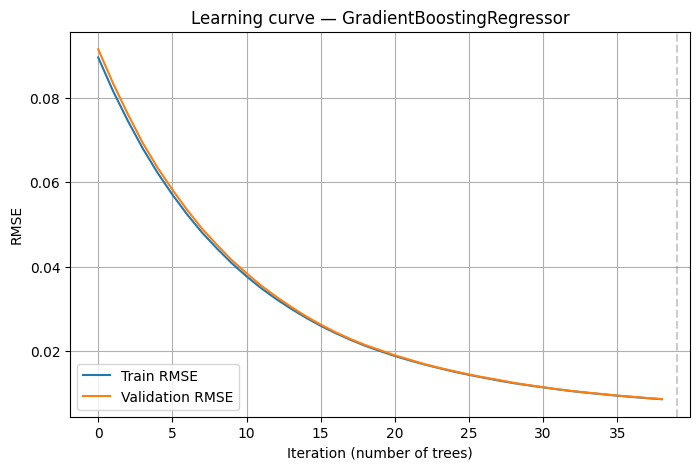

In [64]:
# Списки для RMSE на train и val
train_rmse = []
val_rmse = []

# RMSE по числу деревьев
for y_pred_train in gb.staged_predict(X_train):
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))

for y_pred_val in gb.staged_predict(X_val):
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

# Рисуем график
plt.figure(figsize=(8,5))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.axvline(gb.n_estimators_, color="gray", linestyle="--", alpha=0.4)  # где остановка по early stopping
plt.xlabel("Iteration (number of trees)")
plt.ylabel("RMSE")
plt.title("Learning curve — GradientBoostingRegressor")
plt.legend()
plt.grid(True)
plt.show()

2. LightGBM

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 6402, number of used features: 15
[LightGBM] [Info] Start training from score 0.114537
Training until validation scores don't improve for 10 rounds
[10]	training's rmse: 0.0363177	training's l2: 0.00131898	valid_1's rmse: 0.0370906	valid_1's l2: 0.00137571
[20]	training's rmse: 0.014771	training's l2: 0.000218184	valid_1's rmse: 0.0150601	valid_1's l2: 0.000226807
[30]	training's rmse: 0.00767267	training's l2: 5.88699e-05	valid_1's rmse: 0.00790874	valid_1's l2: 6.25482e-05
[40]	training's rmse: 0.00560212	training's l2: 3.13838e-05	valid_1's rmse: 0.00585836	valid_1's l2: 3.43204e-05
[50]	training's rmse: 0.0049503	training's l2: 2.45055e-05	valid_1's rmse: 0.00525537	vali

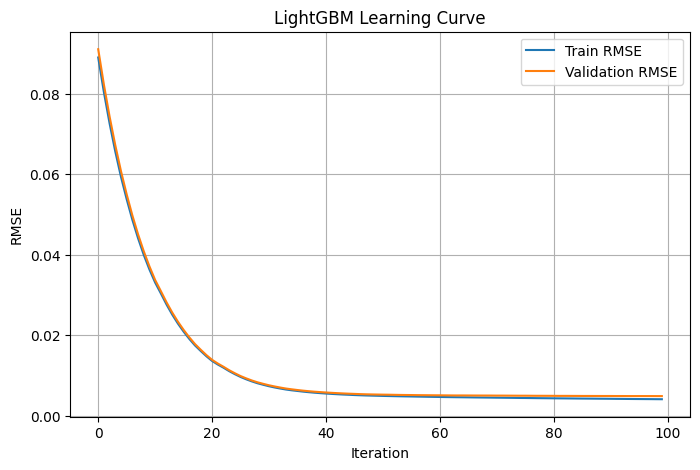

In [65]:
# Модель
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Обучение с eval_set и callback для ранней остановки + логирование
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=10, verbose=True),
        log_evaluation(period=10)  # выводит метрики каждые 10 итераций
    ]
)

# История метрик
evals_result = lgbm.evals_result_

# График обучения
plt.figure(figsize=(8,5))
plt.plot(evals_result['training']['rmse'], label='Train RMSE')
plt.plot(evals_result['valid_1']['rmse'], label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('LightGBM Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

3. Catboost

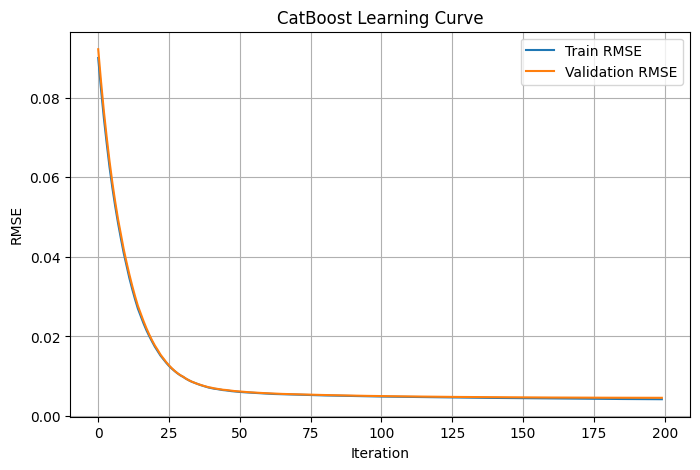

In [66]:
# Модель
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    subsample=0.9,
    random_seed=42,
    verbose=False  # не выводим прогресс
)

# Обучение с eval_set
cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),  # данные для валидации
    use_best_model=False      # True — модель сохранит лучший результат
)

# История метрик
evals_result = cat.get_evals_result()

# График обучения RMSE (по умолчанию метрика для регрессии)
plt.figure(figsize=(8,5))
plt.plot(evals_result['learn']['RMSE'], label='Train RMSE')
plt.plot(evals_result['validation']['RMSE'], label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

4. XGBoost

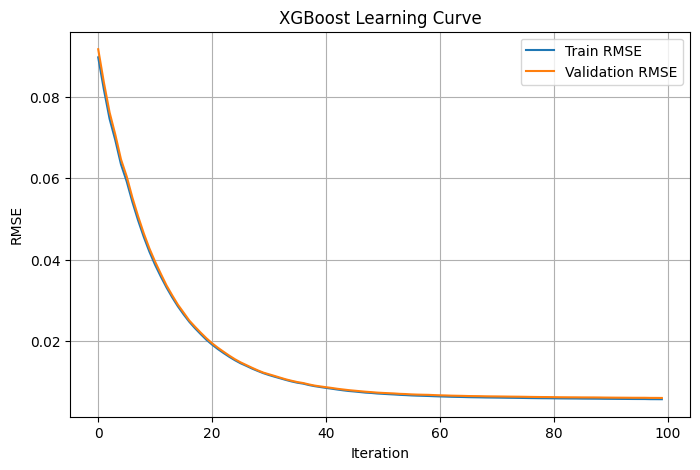

In [67]:
results = xgb.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

plt.figure(figsize=(8, 5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

- С Optuna:

5. GradientBoosting + Optuna
7. LightGBM + Optuna
8. Catboost + Optuna

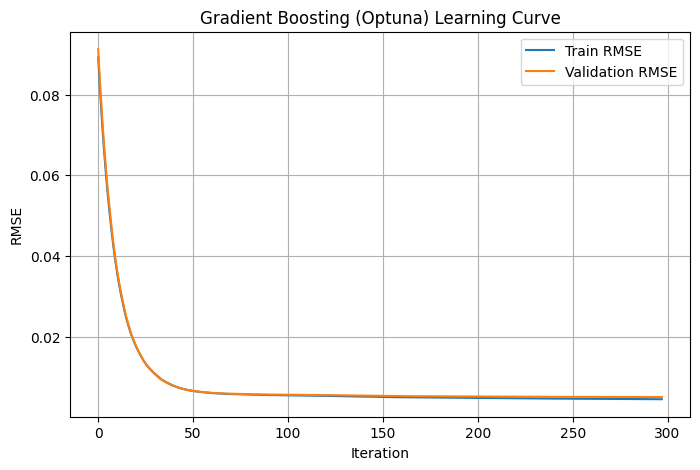

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 6402, number of used features: 15
[LightGBM] [Info] Start training from score 0.114537


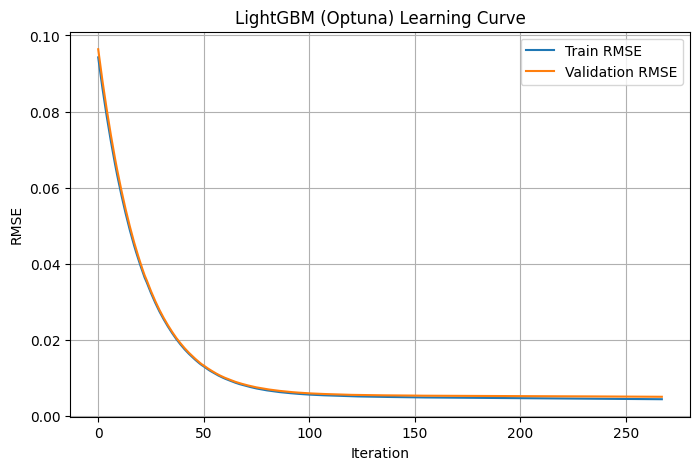

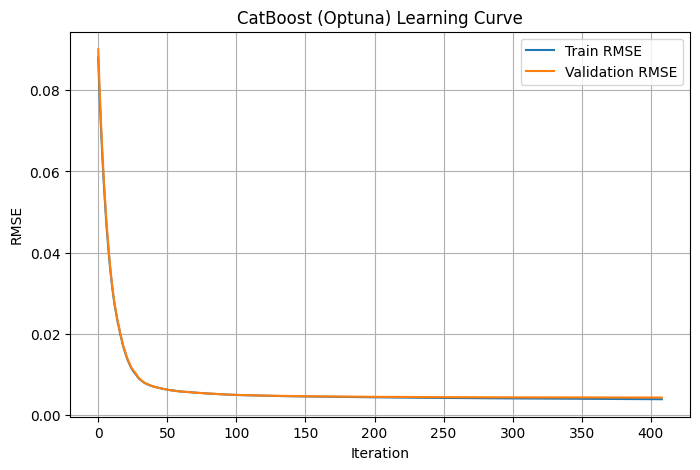

In [68]:
optuna_results_list = []

for m in models:
    params = best_params[m]

    if m == "gb":
        model = GradientBoostingRegressor(**params)
        name = "Gradient Boosting (Optuna)"
        model.fit(X_train, y_train)
        # GradientBoosting не хранит историю, можно использовать staged_predict для RMSE
        train_rmse, val_rmse = [], []
        for y_train_pred, y_val_pred in zip(model.staged_predict(X_train), model.staged_predict(X_val)):
            train_rmse.append(((y_train - y_train_pred)**2).mean()**0.5)
            val_rmse.append(((y_val - y_val_pred)**2).mean()**0.5)

    elif m == "lgbm":
        name = "LightGBM (Optuna)"
        model = LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=10, verbose=False), log_evaluation(period=0)]
        )
        evals_result = model.evals_result_
        train_rmse = evals_result['training']['rmse']
        val_rmse = evals_result['valid_1']['rmse']

    elif m == "cat":
        name = "CatBoost (Optuna)"
        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=False, verbose=False)
        evals_result = model.get_evals_result()
        train_rmse = evals_result['learn']['RMSE']
        val_rmse = evals_result['validation']['RMSE']

    # Строим график обучения
    plt.figure(figsize=(8,5))
    plt.plot(train_rmse, label='Train RMSE')
    plt.plot(val_rmse, label='Validation RMSE')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title(f'{name} Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Сбор метрик в DataFrame (если есть функция collect_metrics)
    optuna_results_list.append(collect_metrics(model, name))

optuna_results = pd.DataFrame(optuna_results_list)

8. XGBoost + Optuna


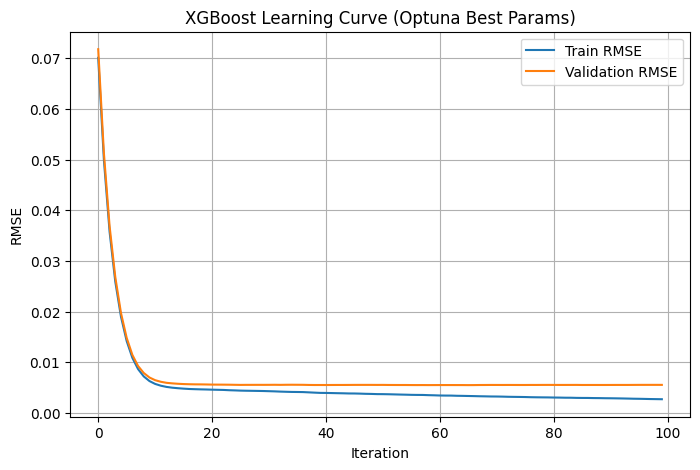

In [69]:
results = xgb_best.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

plt.figure(figsize=(8, 5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve (Optuna Best Params)')
plt.legend()
plt.grid(True)
plt.show()